# Gradient Boosting Credit-Default Models: XGBoost & CatBoost

## Motivation

Tree-based gradient boosting methods complement neural MoE models well:
* **No scaling required** — decision trees are invariant to feature magnitude.
* **Native handling of missing values** — XGBoost and CatBoost both have built-in strategies.
* **Fast training and interpretable feature importance** — critical for regulatory environments.
* **Proven state-of-the-art** on tabular data (Kaggle competitions, financial scoring).

Both models address class imbalance directly via a **class-weight parameter built into the loss**,
analogous to `pos_weight` in the MoE notebook.

### Outline
1. Data loading & preprocessing
2. Class-imbalance analysis
3. Shared evaluation helpers
4. XGBoost — theory, training, evaluation, feature importance
5. CatBoost — theory, training, evaluation, feature importance
6. Side-by-side model comparison
7. Summary

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, f1_score, classification_report,
    precision_score, recall_score,
)

import xgboost as xgb
from catboost import CatBoostClassifier, Pool

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print("XGBoost :", xgb.__version__)
import catboost
print("CatBoost:", catboost.__version__)

XGBoost : 3.2.0
CatBoost: 1.2.10


## 1 · Data Loading & Preprocessing

Identical pipeline to the MoE notebook:
* Remove `age == 0` and sentinel values `delinq_90 ≥ 96`
* Create missing-value indicator flags from `raw` before imputation
* Impute `monthly_income` with median, `dependents` with 0

> **Note**: XGBoost and CatBoost can handle missing values natively, but we keep the
> same preprocessing as the MoE notebook for a fair comparison. The missing-indicator
> columns explicitly expose the missingness signal to all models.

In [2]:
raw = pd.read_csv('../Data/cs-training.csv', index_col=0)

RENAME = {
    'SeriousDlqin2yrs':                        'defaulted',
    'RevolvingUtilizationOfUnsecuredLines':     'unsecured_credit',
    'age':                                      'age',
    'NumberOfTime30-59DaysPastDueNotWorse':     'delinq_30_59',
    'DebtRatio':                                'debt_ratio',
    'MonthlyIncome':                            'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':          'open_credit',
    'NumberOfTimes90DaysLate':                  'delinq_90',
    'NumberRealEstateLoansOrLines':             'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':     'delinq_60_89',
    'NumberOfDependents':                       'dependents',
}
raw = raw.rename(columns=RENAME)

df = raw.copy()
df = df[df['age'] > 0]
df = df[df['delinq_90'] < 96]

df['monthly_income_missing'] = raw.loc[df.index, 'monthly_income'].isna().astype(int)
df['dependents_missing']     = raw.loc[df.index, 'dependents'].isna().astype(int)

df['monthly_income'] = df['monthly_income'].fillna(df['monthly_income'].median())
df['dependents']     = df['dependents'].fillna(0)

FEATURE_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
    'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
    'delinq_60_89', 'dependents', 'monthly_income_missing', 'dependents_missing',
]

print(f"Dataset shape : {df.shape}")
print(f"Default rate  : {df['defaulted'].mean():.3%}")

Dataset shape : (149730, 13)
Default rate  : 6.598%


## 2 · Class-Imbalance Analysis

With ~6.7 % defaults the dataset is heavily imbalanced.

| Model | Imbalance parameter | Effect |
|---|---|---|
| XGBoost | `scale_pos_weight = n_neg / n_pos` | Scales gradient of positive class by this factor |
| CatBoost | `class_weights = [1, n_neg / n_pos]` | Reweights loss contribution per class |

Both are equivalent to upweighting minority-class examples during training.

Train : (104810, 12)  default=6.598%
Val   : (22460, 12)   default=6.598%
Test  : (22460, 12)  default=6.598%

class_ratio (n_neg/n_pos): 14.16


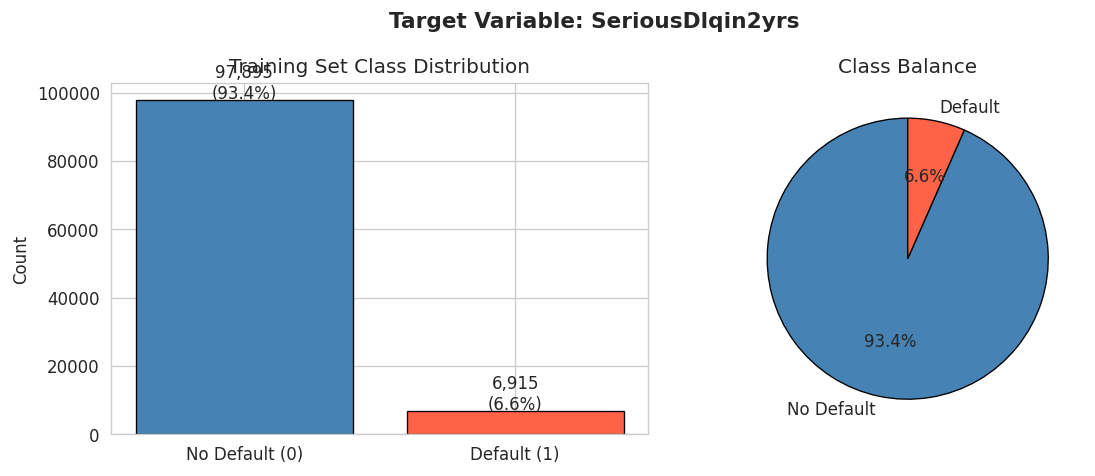

In [3]:
SEED = 42
np.random.seed(SEED)

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['defaulted'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED, stratify=y_temp)

# Tree models don't need scaling, but we scale for consistency with MoE notebook
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
class_ratio = n_neg / n_pos

print(f"Train : {X_train_s.shape}  default={y_train.mean():.3%}")
print(f"Val   : {X_val_s.shape}   default={y_val.mean():.3%}")
print(f"Test  : {X_test_s.shape}  default={y_test.mean():.3%}")
print(f"\nclass_ratio (n_neg/n_pos): {class_ratio:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = [n_neg, n_pos]
axes[0].bar(['No Default (0)', 'Default (1)'], counts,
            color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.8)
for i, v in enumerate(counts):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(y_train):.1%})', ha='center', fontsize=10)
axes[0].set_title('Training Set Class Distribution'); axes[0].set_ylabel('Count')

axes[1].pie(counts, labels=['No Default', 'Default'], colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Class Balance')
plt.suptitle('Target Variable: SeriousDlqin2yrs', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 3 · Shared Evaluation Helpers

To avoid copy-pasting the same threshold sweep, classification reports, and plots for
each model, we define three shared functions used throughout the notebook:

* `get_thresholds` — sweeps val probabilities, returns the max-F1 and precision-targeted thresholds
* `print_evaluation` — prints scalar metrics and classification reports for both thresholds
* `plot_evaluation` — 4-panel plot: two confusion matrices + ROC + PR curve with operating points marked

In [4]:
PREC_TARGET = 0.50   # minimum acceptable Default-class precision (Option 1)


def get_thresholds(y_val, val_probs, prec_target=PREC_TARGET):
    # Sweep 499 candidate thresholds on the validation set
    thr = np.linspace(0.01, 0.99, 499)
    pv  = np.array([precision_score(y_val, val_probs >= t, zero_division=0) for t in thr])
    rv  = np.array([recall_score(y_val,    val_probs >= t, zero_division=0) for t in thr])
    fv  = np.array([f1_score(y_val,        val_probs >= t, zero_division=0) for t in thr])

    # Strategy A: max F1
    idx_f1    = int(np.argmax(fv))
    thresh_f1 = thr[idx_f1]

    # Strategy B: highest recall s.t. precision >= prec_target
    feasible = pv >= prec_target
    if feasible.any():
        idx_prec    = feasible.nonzero()[0][int(np.argmax(rv[feasible]))]
        thresh_prec = thr[idx_prec]
    else:
        idx_prec    = int(np.argmax(pv))
        thresh_prec = thr[idx_prec]
        print(f"  Warning: precision target {prec_target:.0%} never achieved on val; "
              f"using max-precision threshold ({thresh_prec:.3f}).")

    print(f"  Strategy A — Max-F1    : t={thresh_f1:.3f}  "
          f"prec={pv[idx_f1]:.3f}  rec={rv[idx_f1]:.3f}  F1={fv[idx_f1]:.3f}")
    print(f"  Strategy B — Prec≥{prec_target:.0%} : t={thresh_prec:.3f}  "
          f"prec={pv[idx_prec]:.3f}  rec={rv[idx_prec]:.3f}")
    return thresh_f1, thresh_prec, thr, pv, rv


def print_evaluation(name, y_test, test_probs, thresh_f1, thresh_prec, prec_target=PREC_TARGET):
    auc = roc_auc_score(y_test, test_probs)
    ap  = average_precision_score(y_test, test_probs)
    print(f"\n{'='*62}")
    print(f"  {name}")
    print(f"{'='*62}")
    print(f"  ROC-AUC       : {auc:.4f}")
    print(f"  Avg Precision : {ap:.4f}")
    print(f"\n  ── Strategy A: Max-F1 (t={thresh_f1:.3f}) ──")
    print(classification_report(y_test, (test_probs >= thresh_f1).astype(int),
                                target_names=['No Default', 'Default']))
    print(f"  ── Strategy B: Prec≥{prec_target:.0%} (t={thresh_prec:.3f}) ──")
    print(classification_report(y_test, (test_probs >= thresh_prec).astype(int),
                                target_names=['No Default', 'Default']))
    return auc, ap


def plot_evaluation(name, y_test, test_probs, thresh_f1, thresh_prec,
                    prec_target=PREC_TARGET, color='steelblue'):
    pf = (test_probs >= thresh_f1).astype(int)
    pp = (test_probs >= thresh_prec).astype(int)
    auc = roc_auc_score(y_test, test_probs)
    ap  = average_precision_score(y_test, test_probs)

    fig, axes = plt.subplots(1, 4, figsize=(21, 5))

    # Confusion matrices — side by side
    for ax, preds, label in [
        (axes[0], pf, f'Max-F1\n(t={thresh_f1:.3f})'),
        (axes[1], pp, f'Prec≥{prec_target:.0%}\n(t={thresh_prec:.3f})'),
    ]:
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                    xticklabels=['No Default', 'Default'],
                    yticklabels=['No Default', 'Default'], linewidths=0.5)
        ax.set_title(f'{name}\nConfusion Matrix — {label}')
        ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    axes[2].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[2].set_title(f'{name} — ROC Curve')
    axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR'); axes[2].legend()

    # PR curve with operating points
    pc, rc, _ = precision_recall_curve(y_test, test_probs)
    axes[3].plot(rc, pc, color=color, lw=2, label=f'AP = {ap:.4f}')
    axes[3].axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline (prior)')
    axes[3].scatter([recall_score(y_test, pf)], [precision_score(y_test, pf)],
                    color='tomato', s=90, zorder=5, label=f'Max-F1 t={thresh_f1:.3f}')
    axes[3].scatter([recall_score(y_test, pp)], [precision_score(y_test, pp)],
                    color='green', s=90, marker='D', zorder=5,
                    label=f'Prec≥{prec_target:.0%} t={thresh_prec:.3f}')
    axes[3].set_title(f'{name} — PR Curve')
    axes[3].set_xlabel('Recall'); axes[3].set_ylabel('Precision'); axes[3].legend(fontsize=8)

    plt.tight_layout(); plt.show()


print("Helper functions defined: get_thresholds, print_evaluation, plot_evaluation")
print(f"PREC_TARGET = {PREC_TARGET:.0%}")

Helper functions defined: get_thresholds, print_evaluation, plot_evaluation
PREC_TARGET = 50%


## 4 · XGBoost

### Theory

XGBoost (Chen & Guestrin, 2016) fits an ensemble of $T$ decision trees sequentially.
Each tree $f_t$ corrects the residuals of the previous ensemble by minimising a
regularised second-order Taylor expansion of the loss:

$$\mathcal{L}^{(t)} = \sum_i \left[ g_i f_t(x_i) + \tfrac{1}{2} h_i f_t^2(x_i) \right]
+ \Omega(f_t)$$

where $g_i = \partial_{\hat{y}} \ell(y_i, \hat{y}_i)$ and $h_i = \partial^2_{\hat{y}} \ell$ are the
gradient and Hessian of the per-sample loss, and $\Omega(f_t) = \gamma T + \tfrac{1}{2}\lambda \|w\|^2$
penalises tree complexity.

### Handling class imbalance

For binary classification XGBoost uses logistic loss. The `scale_pos_weight` parameter
scales the gradient of positive examples by a constant factor:

$$g_i \leftarrow \texttt{scale\_pos\_weight} \cdot g_i \quad \text{for } y_i = 1$$

Setting `scale_pos_weight` = $n_\text{neg}$ / $n_\text{pos} \approx 14$ makes each default
example contribute as much gradient as 14 non-defaults — equivalent to oversampling.

### Key hyperparameters

| Parameter | Value | Role |
|---|---|---|
| `n_estimators` | 2000 | Max trees; early stopping controls actual count |
| `learning_rate` | 0.05 | Shrinkage per tree |
| `max_depth` | 6 | Tree depth — controls capacity |
| `subsample` | 0.8 | Row subsampling per tree — reduces variance |
| `colsample_bytree` | 0.8 | Feature subsampling per tree |
| `scale_pos_weight` | $n_-/n_+$ | Class-imbalance correction |
| `eval_metric` | `aucpr` | Monitor AUC-PR on validation (better than AUC for imbalance) |
| `early_stopping_rounds` | 30 | Stop when val metric doesn't improve |

In [5]:
xgb_model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=class_ratio,   # imbalance: n_neg / n_pos
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train_s, y_train,
    eval_set=[(X_val_s, y_val)],
    verbose=100,
)

print(f"\nBest iteration : {xgb_model.best_iteration}")
print(f"Best val AUC-PR: {xgb_model.best_score:.4f}")

[0]	validation_0-aucpr:0.35886
[57]	validation_0-aucpr:0.39109

Best iteration : 27
Best val AUC-PR: 0.3926


XGBoost — threshold selection (val):
  Strategy A — Max-F1    : t=0.697  prec=0.395  rec=0.509  F1=0.445
  Strategy B — Prec≥50% : t=0.779  prec=0.502  rec=0.280

  XGBoost
  ROC-AUC       : 0.8514
  Avg Precision : 0.3759

  ── Strategy A: Max-F1 (t=0.697) ──
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.96     20978
     Default       0.39      0.46      0.42      1482

    accuracy                           0.92     22460
   macro avg       0.68      0.71      0.69     22460
weighted avg       0.92      0.92      0.92     22460

  ── Strategy B: Prec≥50% (t=0.779) ──
              precision    recall  f1-score   support

  No Default       0.95      0.98      0.97     20978
     Default       0.52      0.27      0.36      1482

    accuracy                           0.94     22460
   macro avg       0.74      0.63      0.66     22460
weighted avg       0.92      0.94      0.93     22460



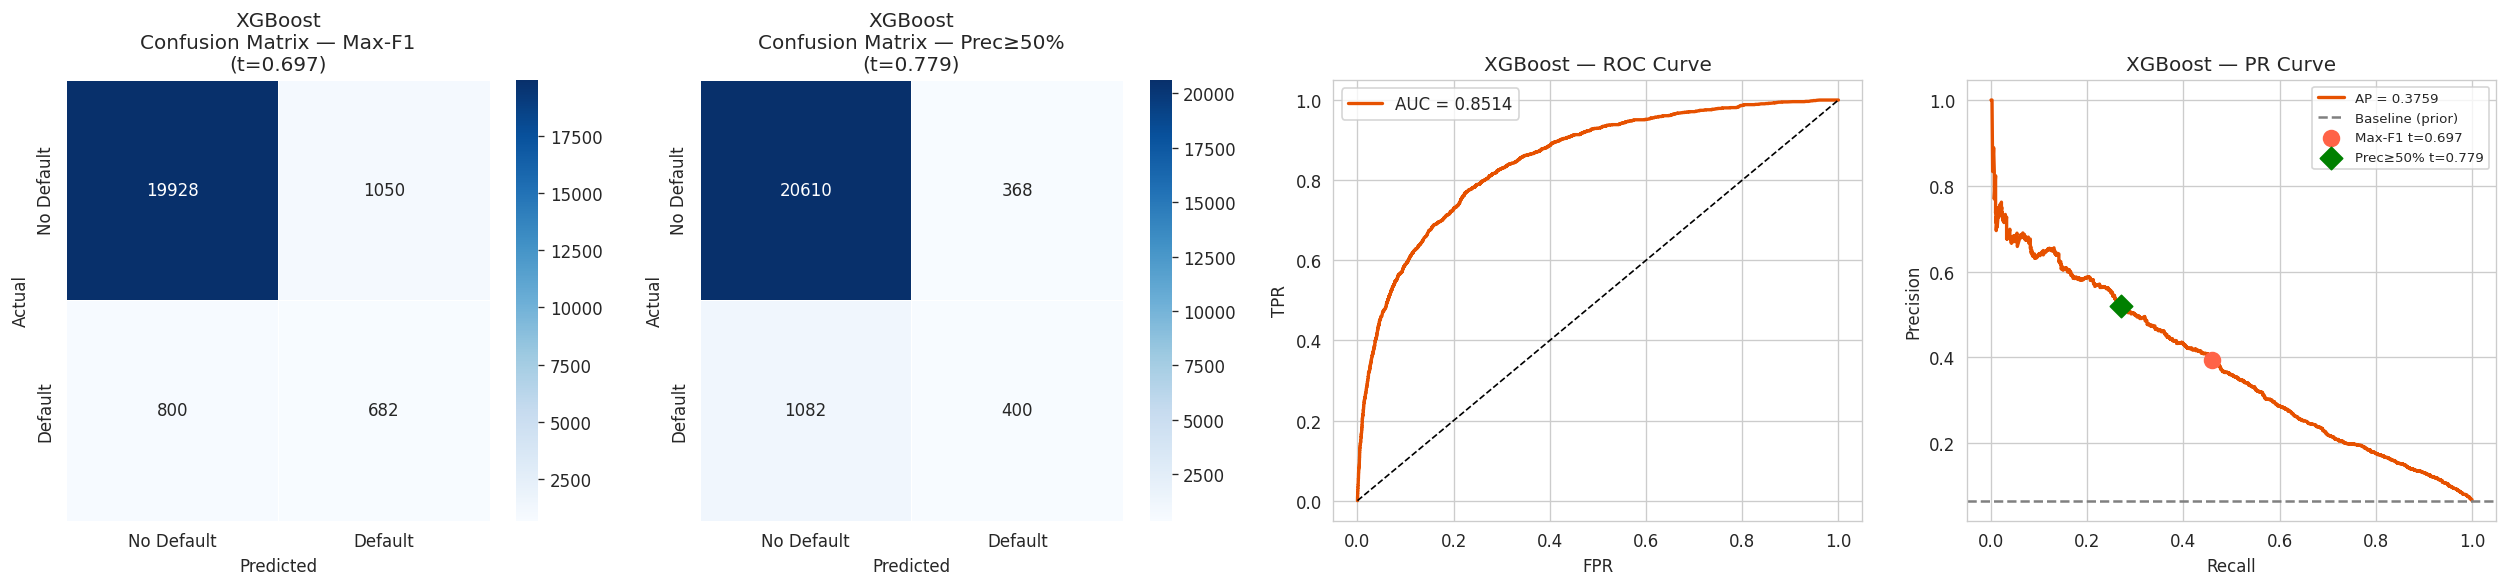

In [6]:
# Threshold sweep on validation set
xgb_val_probs  = xgb_model.predict_proba(X_val_s)[:, 1]
print("XGBoost — threshold selection (val):")
xgb_thresh_f1, xgb_thresh_prec, _, _, _ = get_thresholds(y_val, xgb_val_probs)

# Test-set probabilities
xgb_test_probs = xgb_model.predict_proba(X_test_s)[:, 1]

# Print metrics
xgb_auc, xgb_ap = print_evaluation(
    'XGBoost', y_test, xgb_test_probs, xgb_thresh_f1, xgb_thresh_prec)

# Plots
plot_evaluation('XGBoost', y_test, xgb_test_probs,
                xgb_thresh_f1, xgb_thresh_prec, color='#E65100')

### XGBoost Feature Importance

XGBoost provides three built-in importance metrics:

| Metric | Definition |
|---|---|
| **weight** | Number of times a feature is used to split across all trees |
| **gain** | Average loss reduction from splits using this feature |
| **cover** | Average number of samples affected by splits on this feature |

`gain` is generally most informative for prediction quality.

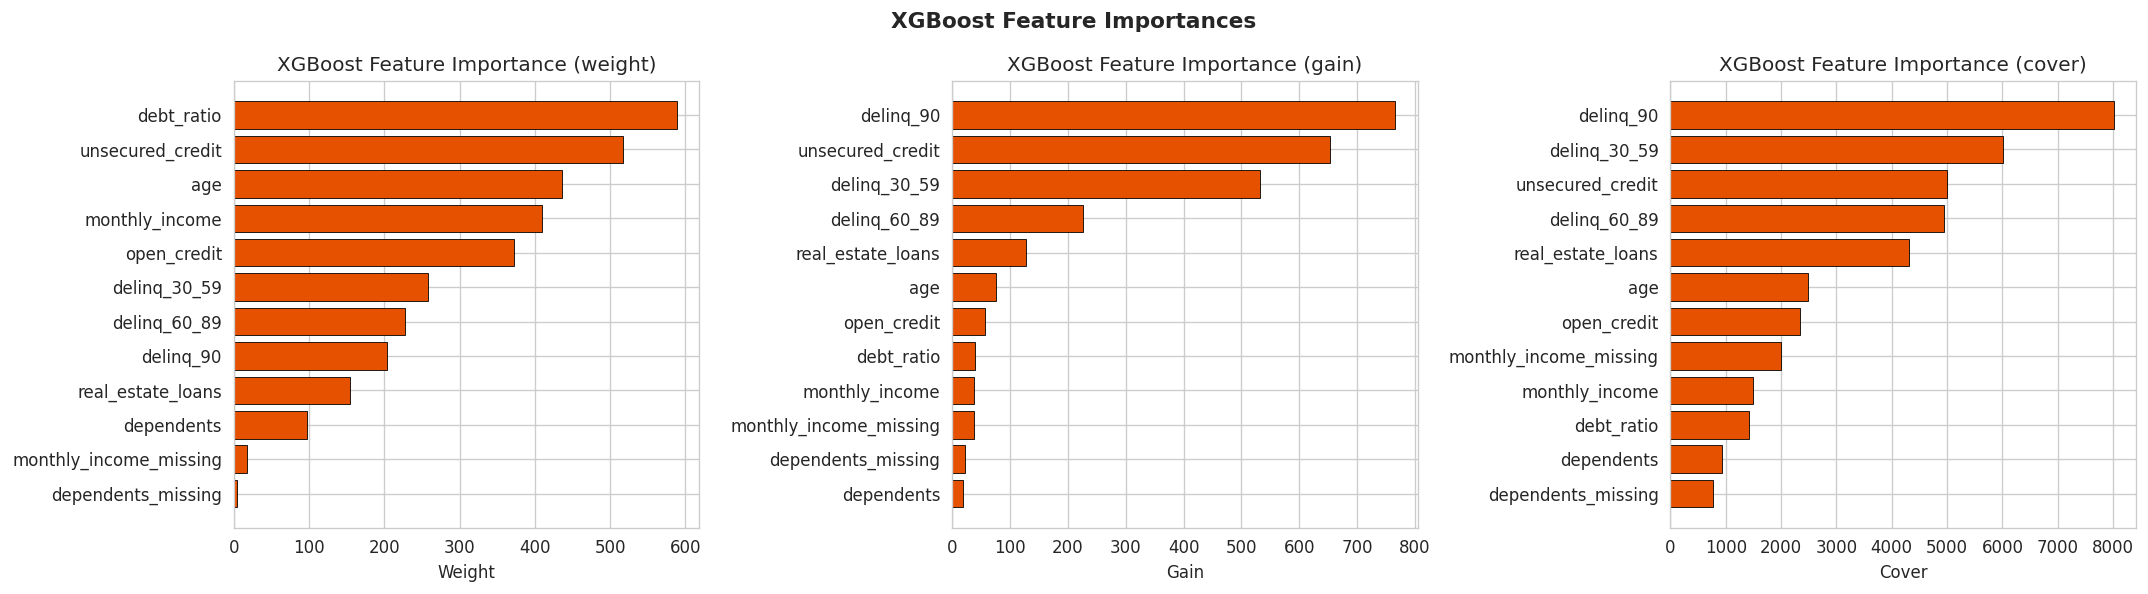

In [7]:
importance_types = ['weight', 'gain', 'cover']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, imp_type in zip(axes, importance_types):
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)
    # Fill zeros for features not used
    feat_scores = {f: scores.get(f'f{i}', 0) for i, f in enumerate(FEATURE_COLS)}
    sorted_feats = sorted(feat_scores, key=feat_scores.get, reverse=True)
    vals = [feat_scores[f] for f in sorted_feats]
    ax.barh(sorted_feats[::-1], vals[::-1], color='#E65100', edgecolor='black', linewidth=0.5)
    ax.set_title(f'XGBoost Feature Importance ({imp_type})')
    ax.set_xlabel(imp_type.capitalize())

plt.suptitle('XGBoost Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5 · CatBoost

### Theory

CatBoost (Prokhorenkova et al., 2018) is a gradient boosting library from Yandex with two key innovations:

**1. Ordered boosting** — prevents target leakage during training. Standard GBDT computes
gradients using the full training set, which leaks information. CatBoost permutes the
training data and computes the gradient for sample $x_i$ using only samples seen *before*
$x_i$ in that permutation:

$$g_i^{(t)} = \nabla_{\hat{y}} \ell\!\left(y_i,\; M^{(t-1)}_{\sigma, i}(x_i)\right)$$

where $M^{(t-1)}_{\sigma, i}$ is the model trained on $\{x_j : \sigma(j) < \sigma(i)\}$.

**2. Symmetric (oblivious) trees** — CatBoost uses the *same* split condition at all
nodes of a given depth level. This produces regularised trees that are fast to evaluate
and less prone to overfitting.

### Handling class imbalance

`class_weights=[w_0, w_1]` scales the loss contribution of each class. Setting
$w_1 = n_\text{neg}/n_\text{pos}$ is equivalent to XGBoost's `scale_pos_weight`.

### Key hyperparameters

| Parameter | Value | Role |
|---|---|---|
| `iterations` | 2000 | Max trees |
| `learning_rate` | 0.05 | Shrinkage |
| `depth` | 6 | Symmetric tree depth |
| `l2_leaf_reg` | 3 | L2 regularisation on leaf weights |
| `class_weights` | $[1, n_-/n_+]$ | Class-imbalance correction |
| `eval_metric` | `AUC` | Validation monitor |
| `early_stopping_rounds` | 30 | Patience on val metric |

In [8]:
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    class_weights=[1, class_ratio],   # imbalance: [w_neg, w_pos]
    eval_metric='AUC',
    early_stopping_rounds=30,
    random_seed=SEED,
    verbose=100,
)

train_pool = Pool(X_train_s, y_train, feature_names=FEATURE_COLS)
val_pool   = Pool(X_val_s,   y_val,   feature_names=FEATURE_COLS)

cat_model.fit(train_pool, eval_set=val_pool)

print(f"\nBest iteration : {cat_model.get_best_iteration()}")
print(f"Best val AUC   : {cat_model.get_best_score()['validation']['AUC']:.4f}")

0:	test: 0.8358664	best: 0.8358664 (0)	total: 95.3ms	remaining: 3m 10s
100:	test: 0.8686525	best: 0.8686525 (100)	total: 632ms	remaining: 11.9s
200:	test: 0.8693879	best: 0.8693944 (181)	total: 1.13s	remaining: 10.2s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.8697103829
bestIteration = 263

Shrink model to first 264 iterations.

Best iteration : 263
Best val AUC   : 0.8697


CatBoost — threshold selection (val):
  Strategy A — Max-F1    : t=0.777  prec=0.400  rec=0.526  F1=0.454
  Strategy B — Prec≥50% : t=0.896  prec=0.500  rec=0.294

  CatBoost
  ROC-AUC       : 0.8570
  Avg Precision : 0.3871

  ── Strategy A: Max-F1 (t=0.777) ──
              precision    recall  f1-score   support

  No Default       0.96      0.95      0.96     20978
     Default       0.41      0.48      0.44      1482

    accuracy                           0.92     22460
   macro avg       0.68      0.72      0.70     22460
weighted avg       0.93      0.92      0.92     22460

  ── Strategy B: Prec≥50% (t=0.896) ──
              precision    recall  f1-score   support

  No Default       0.95      0.98      0.97     20978
     Default       0.52      0.28      0.37      1482

    accuracy                           0.94     22460
   macro avg       0.74      0.63      0.67     22460
weighted avg       0.92      0.94      0.93     22460



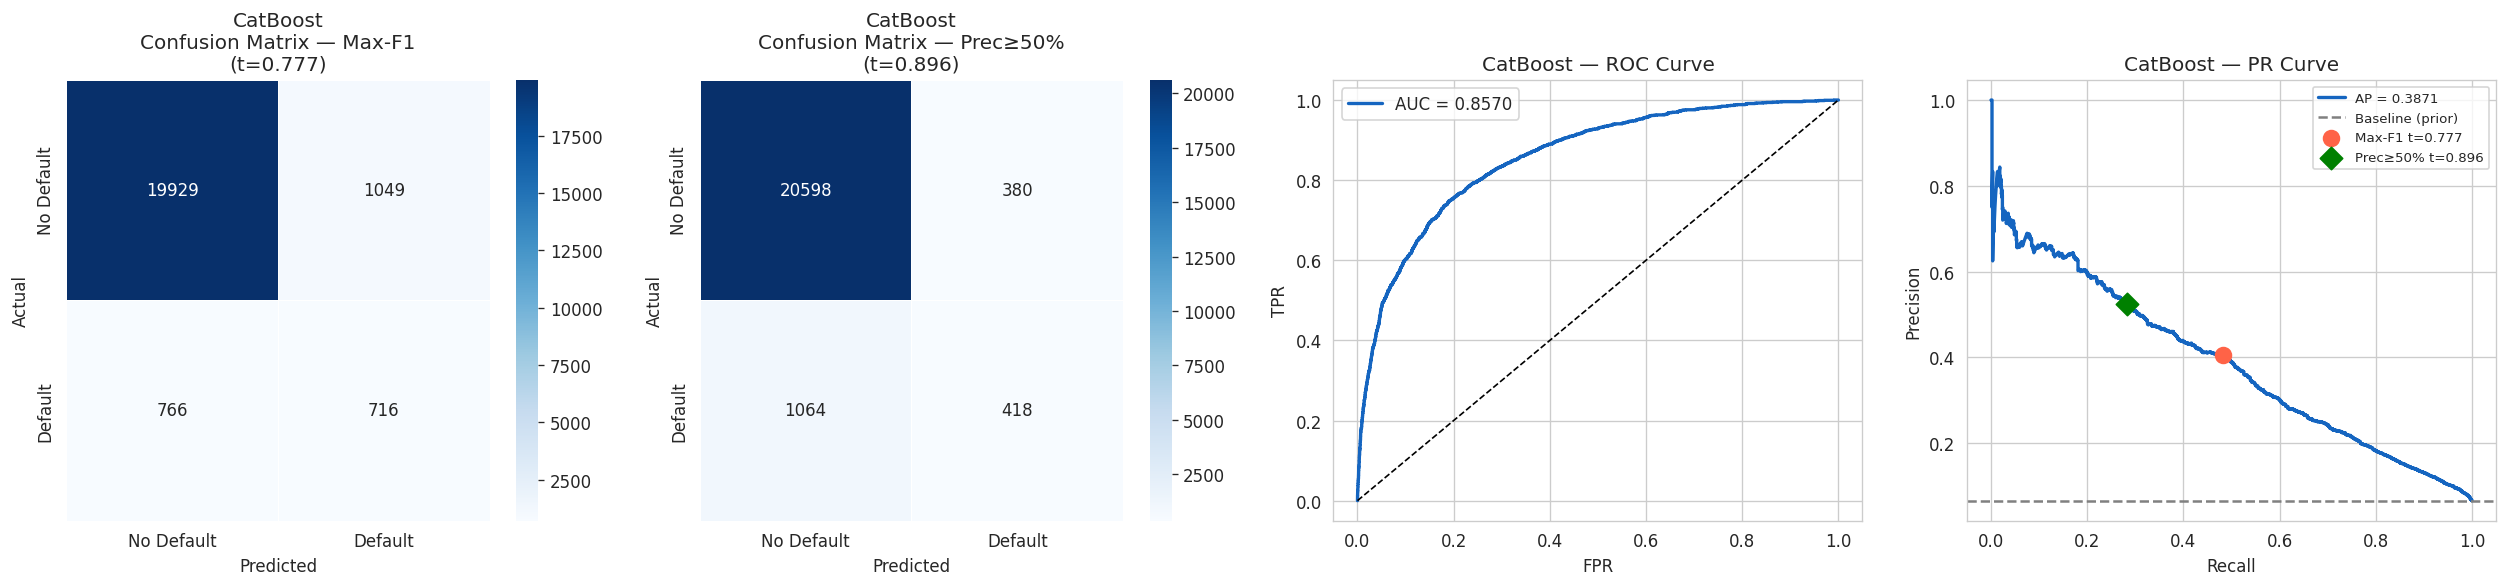

In [9]:
# Threshold sweep on validation set
cat_val_probs  = cat_model.predict_proba(X_val_s)[:, 1]
print("CatBoost — threshold selection (val):")
cat_thresh_f1, cat_thresh_prec, _, _, _ = get_thresholds(y_val, cat_val_probs)

# Test-set probabilities
cat_test_probs = cat_model.predict_proba(X_test_s)[:, 1]

# Print metrics
cat_auc, cat_ap = print_evaluation(
    'CatBoost', y_test, cat_test_probs, cat_thresh_f1, cat_thresh_prec)

# Plots
plot_evaluation('CatBoost', y_test, cat_test_probs,
                cat_thresh_f1, cat_thresh_prec, color='#1565C0')

### CatBoost Feature Importance

CatBoost provides `PredictionValuesChange` (default) and `LossFunctionChange` importances.
`LossFunctionChange` measures the average change in loss when a feature's values are permuted —
a more reliable estimate of true predictive contribution.

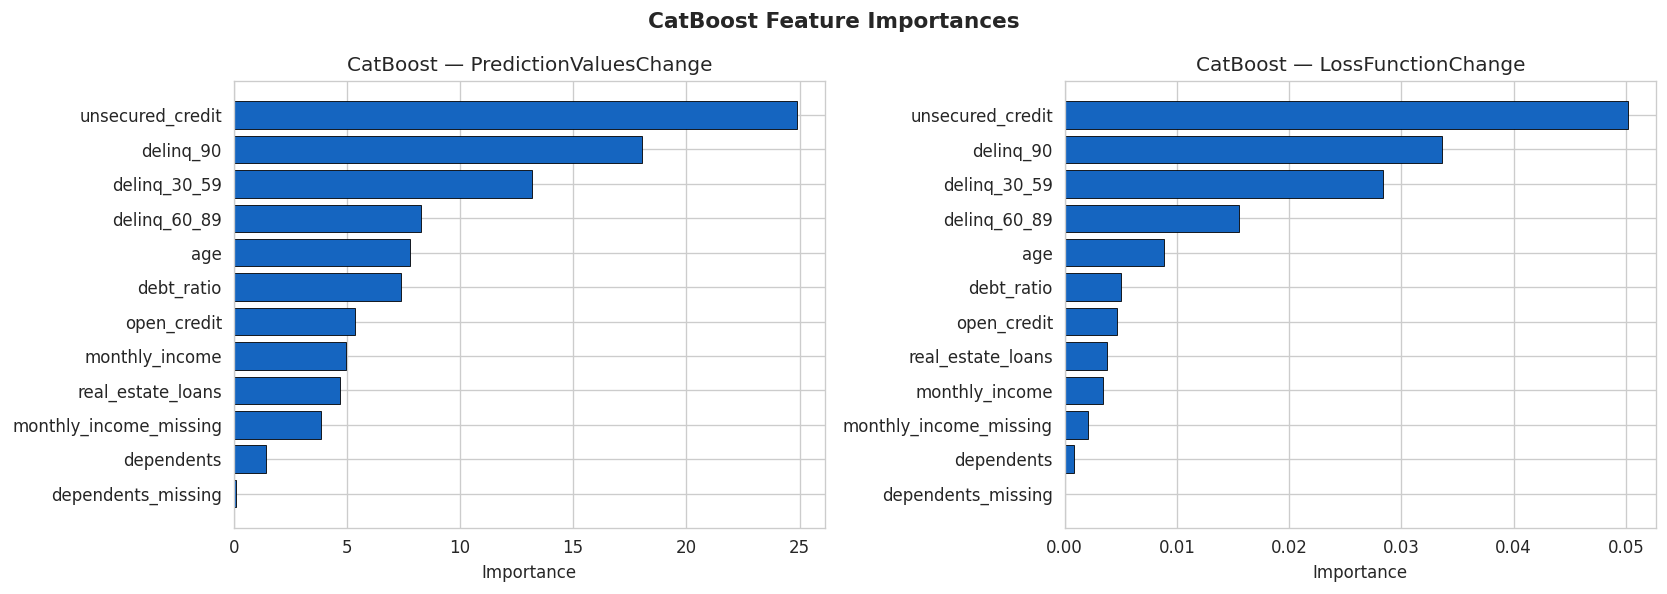

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, imp_type in zip(axes, ['PredictionValuesChange', 'LossFunctionChange']):
    imp = cat_model.get_feature_importance(train_pool, type=imp_type)
    order = np.argsort(imp)
    ax.barh(np.array(FEATURE_COLS)[order], imp[order],
            color='#1565C0', edgecolor='black', linewidth=0.5)
    ax.set_title(f'CatBoost — {imp_type}')
    ax.set_xlabel('Importance')

plt.suptitle('CatBoost Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 6 · CatBoost Hyperparameter Tuning with Optuna

### Why Optuna?

Grid search and random search treat each trial independently. **Optuna** uses a
**Tree-structured Parzen Estimator (TPE)** sampler that builds a probabilistic model of
the objective surface and focuses trials on promising regions — effectively Bayesian
optimisation with a simple API.

### Search space

| Parameter | Range | Scale |
|---|---|---|
| `learning_rate` | 0.01 – 0.3 | log |
| `depth` | 4 – 10 | int |
| `iterations` | 500 – 3000 | int |
| `l2_leaf_reg` | 1 – 10 | float |
| `bagging_temperature` | 0 – 1 | float |
| `random_strength` | 0 – 10 | float |
| `border_count` | 32 – 255 | int |

`early_stopping_rounds=50` is fixed inside each trial so `iterations` acts as an upper
bound — trials terminate early if val AUC stops improving, keeping each trial fast.

**Objective**: maximise validation ROC-AUC (same as existing CatBoost baseline).

In [11]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

N_TRIALS = 50   # ~30-60 min depending on hardware; reduce to 20 for a quick run

def objective(trial):
    params = {
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':              trial.suggest_int('depth', 4, 10),
        'iterations':         trial.suggest_int('iterations', 500, 3000),
        'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':    trial.suggest_float('random_strength', 0.0, 10.0),
        'border_count':       trial.suggest_int('border_count', 32, 255),
        # fixed settings — same as baseline
        'class_weights':      [1, class_ratio],
        'eval_metric':        'AUC',
        'early_stopping_rounds': 50,
        'random_seed':        SEED,
        'verbose':            0,
    }
    model = CatBoostClassifier(**params)
    model.fit(train_pool, eval_set=val_pool)
    # best_score_ is populated by early stopping
    return model.best_score_['validation']['AUC']

sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest val AUC : {study.best_value:.5f}")
print("Best params  :")
for k, v in study.best_params.items():
    print(f"  {k:<25} {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best val AUC : 0.87051
Best params  :
  learning_rate             0.029857360490992486
  depth                     7
  iterations                1285
  l2_leaf_reg               9.043249271796242
  bagging_temperature       0.9508380949542059
  random_strength           7.913191975793807
  border_count              67


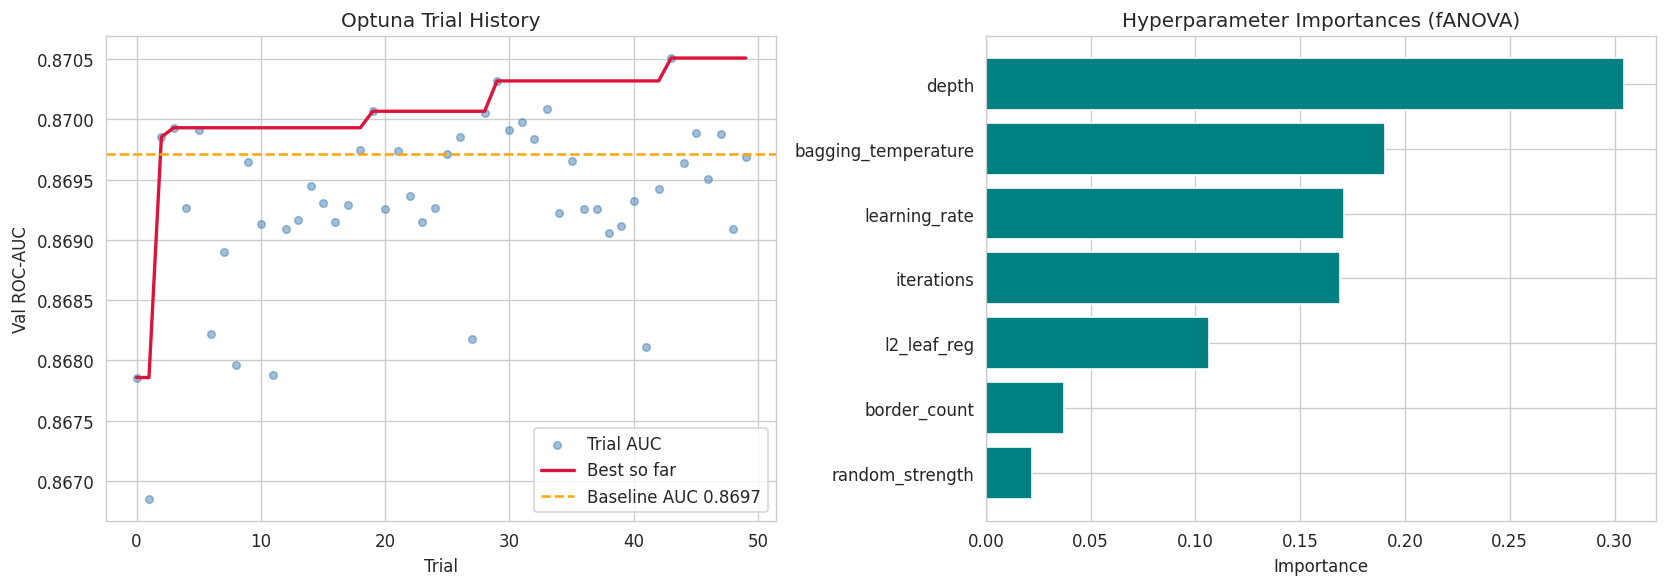

In [12]:
# Optuna optimisation history and parameter importance
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(y_val, cat_val_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Trial history ──────────────────────────────────────────────────────────────
trial_nums  = [t.number for t in study.trials]
trial_aucs  = [t.value  for t in study.trials]
best_so_far = [max(trial_aucs[:i+1]) for i in range(len(trial_aucs))]

axes[0].scatter(trial_nums, trial_aucs, s=20, alpha=0.5, color='steelblue', label='Trial AUC')
axes[0].plot(trial_nums, best_so_far, color='crimson', lw=2, label='Best so far')
axes[0].axhline(baseline_auc, color='orange', lw=1.5, ls='--',
                label=f'Baseline AUC {baseline_auc:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val ROC-AUC')
axes[0].set_title('Optuna Trial History')
axes[0].legend()

# ── Parameter importances ──────────────────────────────────────────────────────
importances = optuna.importance.get_param_importances(study)
params_list = list(importances.keys())
imp_vals    = list(importances.values())

axes[1].barh(params_list[::-1], imp_vals[::-1], color='teal')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importances (fANOVA)')

plt.tight_layout()
plt.show()

### Tuned CatBoost — Final Training & Evaluation

Retrain on the full train split using the best hyperparameters found by Optuna,
then evaluate on the held-out test set using the same two threshold strategies.

0:	test: 0.7998037	best: 0.7998037 (0)	total: 4.92ms	remaining: 6.32s
100:	test: 0.8652521	best: 0.8652521 (100)	total: 629ms	remaining: 7.37s
200:	test: 0.8671918	best: 0.8671918 (200)	total: 1.22s	remaining: 6.6s
300:	test: 0.8678022	best: 0.8678208 (299)	total: 1.8s	remaining: 5.88s
400:	test: 0.8682764	best: 0.8682764 (400)	total: 2.52s	remaining: 5.55s
500:	test: 0.8699309	best: 0.8699498 (498)	total: 3.31s	remaining: 5.18s
600:	test: 0.8704103	best: 0.8705086 (592)	total: 4.01s	remaining: 4.57s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8705085811
bestIteration = 592

Shrink model to first 593 iterations.
  Strategy A — Max-F1    : t=0.762  prec=0.395  rec=0.544  F1=0.458
  Strategy B — Prec≥50% : t=0.888  prec=0.503  rec=0.316
TUNED CatBoost — Test Set Results

  CatBoost (Tuned)
  ROC-AUC       : 0.8564
  Avg Precision : 0.3838

  ── Strategy A: Max-F1 (t=0.762) ──
              precision    recall  f1-score   support

  No Default       0.96      0.95 

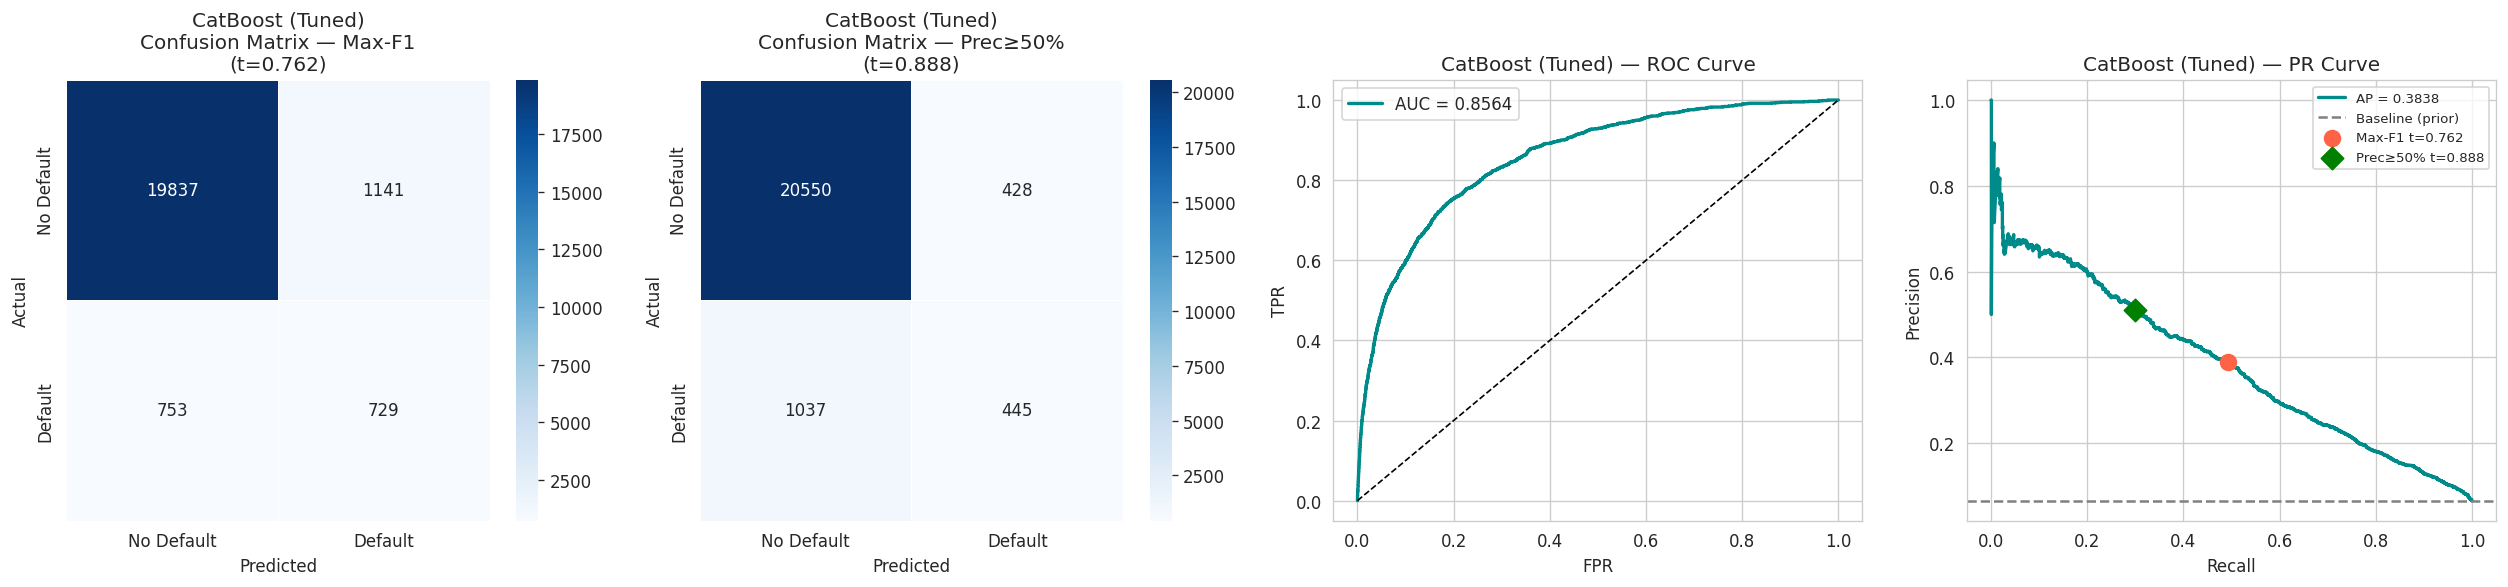

In [13]:
# Retrain with best params (early stopping still active)
best_params = study.best_params.copy()
best_params.update({
    'class_weights':         [1, class_ratio],
    'eval_metric':           'AUC',
    'early_stopping_rounds': 50,
    'random_seed':           SEED,
    'verbose':               100,
})

cat_tuned = CatBoostClassifier(**best_params)
cat_tuned.fit(train_pool, eval_set=val_pool)

# Threshold sweep + evaluation + 4-panel plot
cat_tuned_val_probs  = cat_tuned.predict_proba(X_val_s)[:, 1]
cat_tuned_test_probs = cat_tuned.predict_proba(X_test_s)[:, 1]

thresh_f1_tuned, thresh_prec_tuned, _, _, _ = get_thresholds(y_val, cat_tuned_val_probs)

print("=" * 60)
print("TUNED CatBoost — Test Set Results")
print("=" * 60)
print_evaluation("CatBoost (Tuned)", y_test, cat_tuned_test_probs,
                 thresh_f1_tuned, thresh_prec_tuned)
plot_evaluation("CatBoost (Tuned)", y_test, cat_tuned_test_probs,
                thresh_f1_tuned, thresh_prec_tuned, color='darkcyan')

                     AUC     AP  F1@F1thr  F1@Pthr
Model                                             
CatBoost Baseline 0.8570 0.3871    0.4410   0.3667
CatBoost Tuned    0.8564 0.3838    0.4350   0.3779


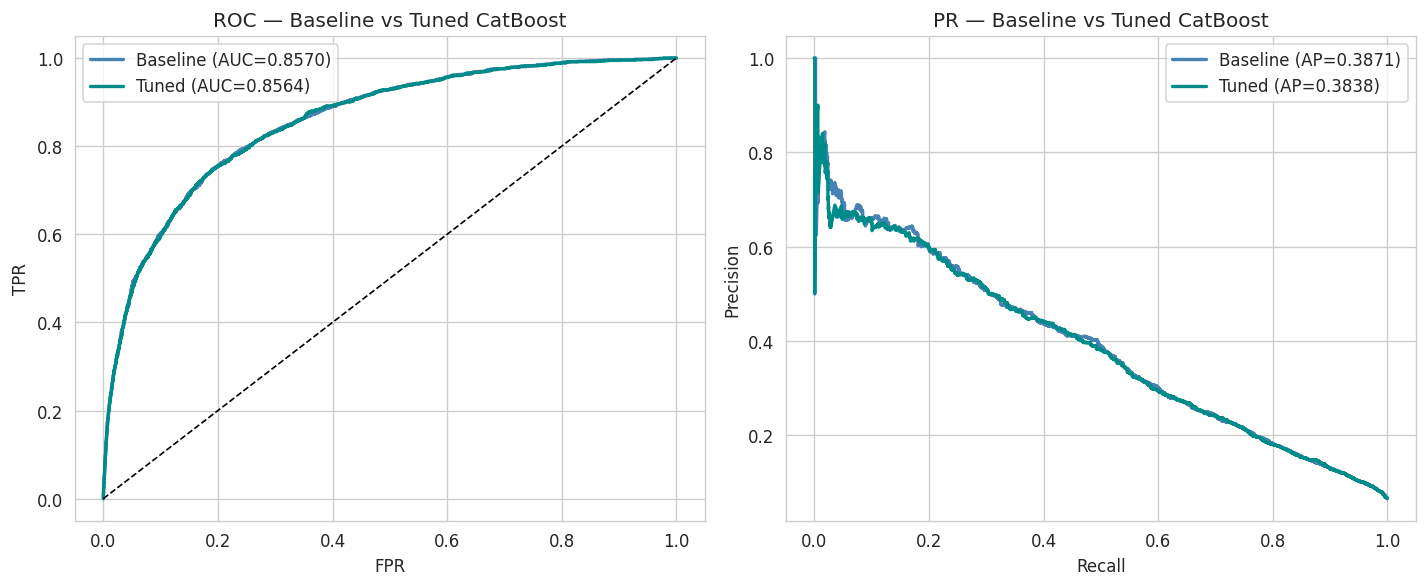

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve, precision_recall_curve

# ── Baseline vs Tuned CatBoost comparison ─────────────────────────────────────
def model_summary(name, y_test, test_probs, thresh_f1, thresh_prec):
    return {
        'Model':    name,
        'AUC':      roc_auc_score(y_test, test_probs),
        'AP':       average_precision_score(y_test, test_probs),
        'F1@F1thr': f1_score(y_test, test_probs >= thresh_f1,   zero_division=0),
        'F1@Pthr':  f1_score(y_test, test_probs >= thresh_prec, zero_division=0),
    }

# cat_thresh_f1 / cat_thresh_prec already defined in the baseline evaluation cell
rows = [
    model_summary("CatBoost Baseline", y_test, cat_test_probs,
                  cat_thresh_f1, cat_thresh_prec),
    model_summary("CatBoost Tuned",    y_test, cat_tuned_test_probs,
                  thresh_f1_tuned, thresh_prec_tuned),
]

import pandas as pd
cmp_df = pd.DataFrame(rows).set_index('Model')
print(cmp_df.to_string(float_format='{:.4f}'.format))

# ── Overlaid ROC + PR ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, probs, color in [
    ("Baseline", cat_test_probs,       'steelblue'),
    ("Tuned",    cat_tuned_test_probs, 'darkcyan'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val      = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.4f})')

    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap_val        = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap_val:.4f})')

axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — Baseline vs Tuned CatBoost'); axes[0].legend()

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR — Baseline vs Tuned CatBoost'); axes[1].legend()

plt.tight_layout()
plt.show()

## 7 · Model Comparison

We compare XGBoost and CatBoost (baseline) head-to-head on the same test set using
both threshold strategies. The tuned CatBoost is compared separately in Section 6.

In [15]:
# Collect results for all models and both thresholds
models_info = [
    ('XGBoost',  xgb_test_probs, xgb_thresh_f1, xgb_thresh_prec, '#E65100'),
    ('CatBoost', cat_test_probs, cat_thresh_f1, cat_thresh_prec, '#1565C0'),
]

rows = []
for name, probs, tf1, tprec, _ in models_info:
    pf1   = (probs >= tf1).astype(int)
    pprec = (probs >= tprec).astype(int)
    rows.append({
        'Model':      name,
        'ROC-AUC':    roc_auc_score(y_test, probs),
        'Avg Prec':   average_precision_score(y_test, probs),
        # Max-F1 threshold metrics
        'Prec (F1 t)': precision_score(y_test, pf1),
        'Rec  (F1 t)': recall_score(y_test, pf1),
        'F1   (F1 t)': f1_score(y_test, pf1),
        # Precision-targeted threshold metrics
        f'Prec (P{int(PREC_TARGET*100)} t)': precision_score(y_test, pprec),
        f'Rec  (P{int(PREC_TARGET*100)} t)': recall_score(y_test, pprec),
        f'F1   (P{int(PREC_TARGET*100)} t)': f1_score(y_test, pprec),
    })

cmp_df = pd.DataFrame(rows).set_index('Model')
pd.set_option('display.float_format', '{:.4f}'.format)
print("\nModel Comparison — Test Set")
print(cmp_df.to_string())


Model Comparison — Test Set
          ROC-AUC  Avg Prec  Prec (F1 t)  Rec  (F1 t)  F1   (F1 t)  Prec (P50 t)  Rec  (P50 t)  F1   (P50 t)
Model                                                                                                       
XGBoost    0.8514    0.3759       0.3938       0.4602       0.4244        0.5208        0.2699        0.3556
CatBoost   0.8570    0.3871       0.4057       0.4831       0.4410        0.5238        0.2821        0.3667


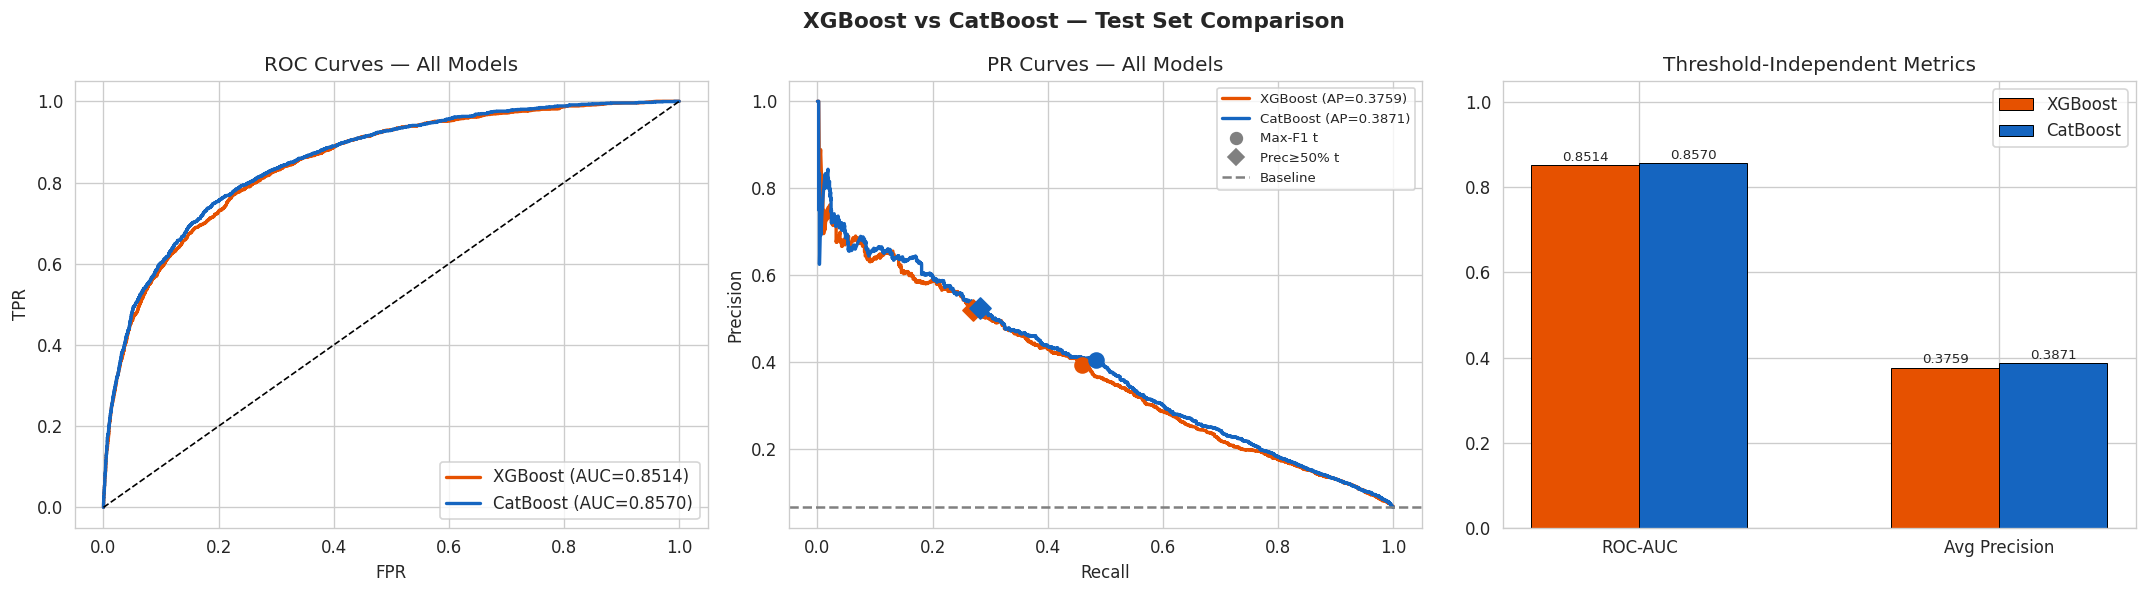

In [16]:
# ── Overlaid ROC curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, probs, tf1, tprec, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curves — All Models')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()

# ── Overlaid PR curves ───────────────────────────────────────────────────────
for name, probs, tf1, tprec, color in models_info:
    pc, rc, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rc, pc, color=color, lw=2, label=f'{name} (AP={ap:.4f})')
    # Mark both operating points
    axes[1].scatter([recall_score(y_test, (probs >= tf1).astype(int))],
                    [precision_score(y_test, (probs >= tf1).astype(int))],
                    color=color, s=80, zorder=5)
    axes[1].scatter([recall_score(y_test, (probs >= tprec).astype(int))],
                    [precision_score(y_test, (probs >= tprec).astype(int))],
                    color=color, s=80, marker='D', zorder=5)
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', label='Baseline')
# Legend for markers
from matplotlib.lines import Line2D
axes[1].legend(handles=axes[1].lines[:2] + [
    Line2D([0],[0], marker='o', color='gray', label='Max-F1 t', markersize=7, linestyle=''),
    Line2D([0],[0], marker='D', color='gray', label=f'Prec≥{PREC_TARGET:.0%} t', markersize=7, linestyle=''),
] + [axes[1].lines[2]], fontsize=8)
axes[1].set_title('PR Curves — All Models')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')

# ── Bar chart: ROC-AUC and Avg Precision ─────────────────────────────────────
metric_labels = ['ROC-AUC', 'Avg Precision']
x = np.arange(len(metric_labels))
width = 0.3
for i, (name, probs, _, _, color) in enumerate(models_info):
    vals = [roc_auc_score(y_test, probs), average_precision_score(y_test, probs)]
    bars = axes[2].bar(x + i*width, vals, width, label=name, color=color,
                       edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, vals):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{v:.4f}', ha='center', va='bottom', fontsize=8)
axes[2].set_xticks(x + width/2); axes[2].set_xticklabels(metric_labels)
axes[2].set_title('Threshold-Independent Metrics')
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.suptitle('XGBoost vs CatBoost — Test Set Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

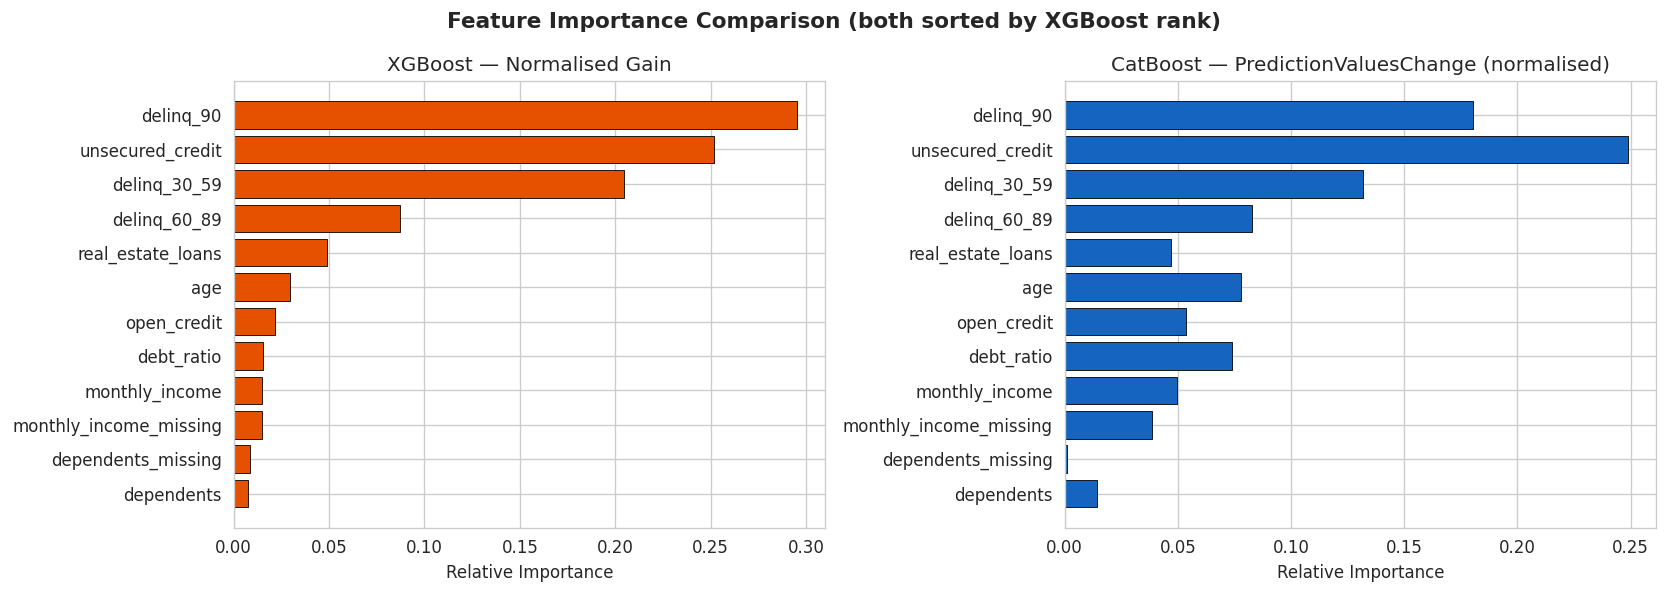

In [17]:
# Normalised gain (XGBoost) vs PredictionValuesChange (CatBoost) — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost gain, normalised to sum=1
xgb_scores  = xgb_model.get_booster().get_score(importance_type='gain')
xgb_imp     = {f: xgb_scores.get(f'f{i}', 0) for i, f in enumerate(FEATURE_COLS)}
total       = sum(xgb_imp.values()) or 1
xgb_imp_n   = {k: v/total for k, v in xgb_imp.items()}

# CatBoost PredictionValuesChange, normalised
cat_imp_raw = cat_model.get_feature_importance(train_pool, type='PredictionValuesChange')
cat_imp_n   = dict(zip(FEATURE_COLS, cat_imp_raw / (cat_imp_raw.sum() or 1)))

# Sort by XGBoost importance
order = sorted(FEATURE_COLS, key=lambda f: xgb_imp_n[f])
xgb_vals = [xgb_imp_n[f] for f in order]
cat_vals = [cat_imp_n[f]  for f in order]

y_pos = np.arange(len(order))
axes[0].barh(y_pos, xgb_vals, color='#E65100', edgecolor='black', linewidth=0.5)
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(order)
axes[0].set_title('XGBoost — Normalised Gain'); axes[0].set_xlabel('Relative Importance')

axes[1].barh(y_pos, cat_vals, color='#1565C0', edgecolor='black', linewidth=0.5)
axes[1].set_yticks(y_pos); axes[1].set_yticklabels(order)
axes[1].set_title('CatBoost — PredictionValuesChange (normalised)')
axes[1].set_xlabel('Relative Importance')

plt.suptitle('Feature Importance Comparison (both sorted by XGBoost rank)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 7 · Summary

### Architecture Comparison

| | XGBoost | CatBoost |
|---|---|---|
| Tree type | Standard CART | Symmetric (oblivious) |
| Gradient computation | Standard GBDT | Ordered boosting (no leakage) |
| Imbalance parameter | `scale_pos_weight = n_neg/n_pos` | `class_weights = [1, n_neg/n_pos]` |
| Missing values | Built-in (learn direction) | Built-in |
| Early stopping metric | AUC-PR (`aucpr`) | AUC |

### Threshold Strategies Recap

| Strategy | Tuning knob | Trade-off |
|---|---|---|
| Max-F1 | — | Balanced precision / recall |
| Precision-targeted | `PREC_TARGET` | Set a precision floor; recall adjusts accordingly |

### Feature Importance Consistency

Both models consistently rank delinquency features (`delinq_90`, `delinq_30_59`, `delinq_60_89`)
and `unsecured_credit` as top predictors — consistent with the reference R analysis (Ngobeni)
and the Mutual Information results from the EDA notebook.

### Practical Recommendation

* Use **CatBoost** if you need the strongest out-of-box AUC with minimal tuning.
* Use **XGBoost** if you need faster distributed training or tighter sklearn integration.
* For regulatory reporting (SR 11-7), prefer the precision-targeted threshold at ≥ 50 % precision
  to reduce false positive rate, accepting a lower recall.